In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

In [3]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])


In [6]:

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


 ### Sales in two regions

In [8]:
region1 = df[df['Region'] == 'West']['Sales']
region2 = df[df['Region'] == 'East']['Sales']

t_stat, p_value = stats.ttest_ind(region1, region2, equal_var=False)
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Significant difference in sales between West and East regions.")
else:
    print("No significant difference.")

T-statistic: -0.7961, P-value: 0.4260
No significant difference.


### Category VS Region

In [9]:
contingency = pd.crosstab(df['Category'], df['Region'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi2: {chi2:.4f}, P-value: {p:.4f}")

Chi2: 3.6619, P-value: 0.7223


### Average Sales

In [11]:
mean_sales = df['Sales'].mean()
sem = stats.sem(df['Sales'])
ci = stats.t.interval(0.95, len(df['Sales'])-1, loc=mean_sales, scale=sem)
print(f"95%  average Sales: {ci}")

95%  average Sales: (np.float64(217.63747489897534), np.float64(242.0785267620212))


### Time Series Analysis

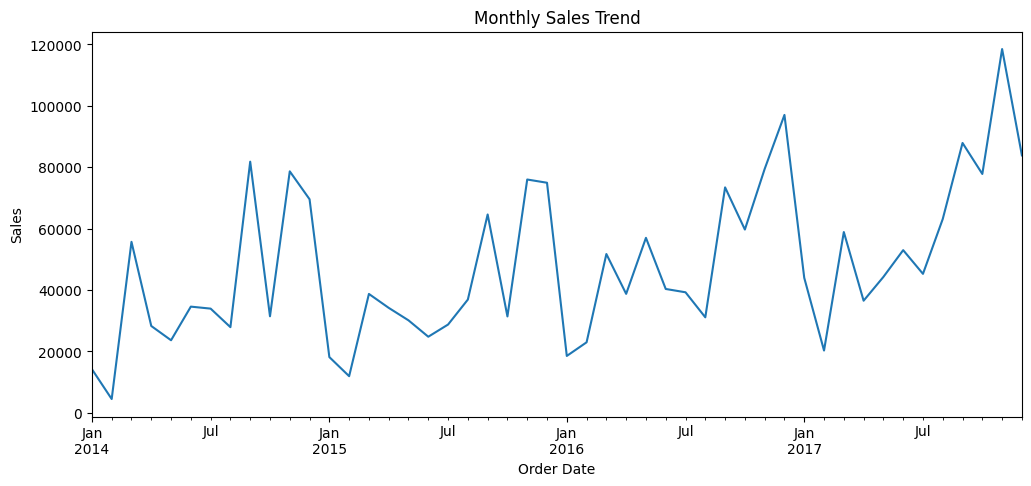

In [12]:
ts = df.set_index('Order Date').resample('ME')['Sales'].sum()

plt.figure(figsize=(12,5))
ts.plot(title='Monthly Sales Trend')
plt.ylabel('Sales')
plt.show()


### Simple moving average forecast

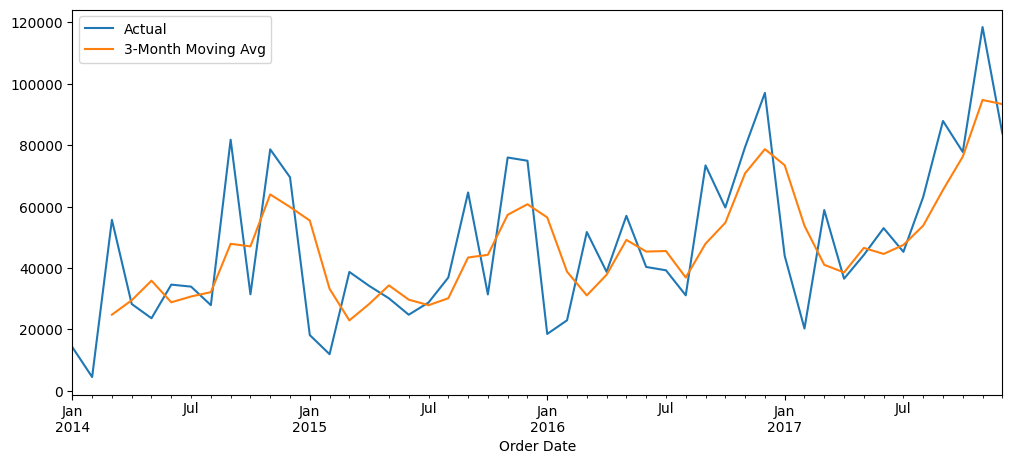

In [13]:

ts_ma = ts.rolling(window=3).mean()
plt.figure(figsize=(12,5))
ts.plot(label='Actual')
ts_ma.plot(label='3-Month Moving Avg')
plt.legend()
plt.show()

### Clustering

In [16]:
customer_df = df.groupby('Customer ID').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).reset_index()

X = customer_df[['Sales', 'Profit', 'Quantity']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



### Elbow method

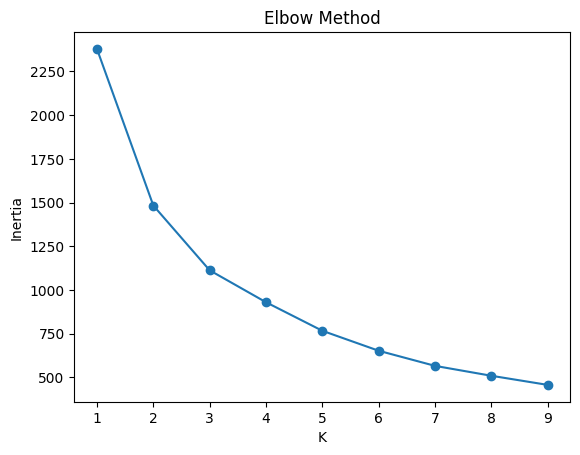

In [15]:
inertia = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

### K-Means + PCA

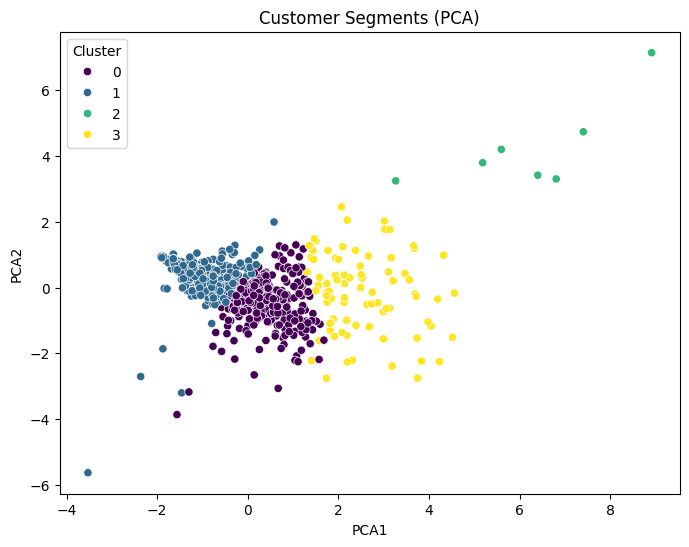

                Sales       Profit   Quantity
Cluster                                      
0         3323.222561   312.307007  63.222222
1         1389.027883   101.998852  29.475369
2        14172.628571  5912.249300  56.142857
3         7795.783607  1335.476645  81.156627


In [17]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_df['Cluster'] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
customer_df['PCA1'] = pca_result[:,0]
customer_df['PCA2'] = pca_result[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=customer_df, x='PCA1', y='PCA2', hue='Cluster', palette='viridis')
plt.title('Customer Segments (PCA)')
plt.show()

print(customer_df.groupby('Cluster')[['Sales','Profit','Quantity']].mean())

### Linear Regression 

In [18]:
features = df[['Quantity', 'Discount', 'Profit']]
target = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

coeff = pd.DataFrame({'Feature': features.columns, 'Coefficient': model.coef_})
print(coeff.sort_values('Coefficient', key=abs, ascending=False))

R²: -0.15181720106063912
MAE: 245.07556984450275
RMSE: 824.8499599151104
    Feature  Coefficient
1  Discount   249.571780
0  Quantity    41.550264
2    Profit     1.561674
